In [1]:
import os
import time
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score,classification_report,confusion_matrix


In [3]:
X_train=pd.read_csv("data/sampled/X_train_balanced.csv")
X_test=pd.read_csv("data/sampled/X_test.csv")
Y_train=pd.read_csv("data/sampled/Y_train_balanced.csv").squeeze()
Y_test=pd.read_csv("data/sampled/Y_test.csv").squeeze()

In [5]:
print(X_train.shape)  #verify dataset
print(X_test.shape)
print(Y_train.shape)
print(Y_test.shape)

(1002606, 78)
(504160, 78)
(1002606,)
(504160,)


In [7]:
xgb=XGBClassifier(                                  #build model
    objective="multi:softmax",
    num_class=len(np.unique(Y_train)),
    n_estimators=200,
    learning_rate=0.1,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=43,
    tree_method="hist",
    eval_metric="mlogloss"
    
)

In [9]:
from sklearn.preprocessing import LabelEncoder #encoding

le = LabelEncoder()

Y_train = le.fit_transform(Y_train)
Y_test = le.transform(Y_test)
print(Y_train[:10])
print(le.classes_)

[0 0 0 0 0 0 2 0 0 0]
['BENIGN' 'Bot' 'DDoS' 'DoS GoldenEye' 'DoS Hulk' 'DoS Slowhttptest'
 'DoS slowloris' 'FTP-Patator' 'Heartbleed' 'Infiltration' 'PortScan'
 'SSH-Patator' 'Web Attack � Brute Force' 'Web Attack � Sql Injection'
 'Web Attack � XSS']


In [11]:
start_train=time.time()              #train model
xgb.fit(X_train,Y_train)
end_train=time.time()
training_time=end_train-start_train
print(f"Training Time: {training_time:.2f} seconds")

Training Time: 443.79 seconds


In [13]:
joblib.dump(xgb,"models/smote_result/xgboost.pk2")

['models/smote_result/xgboost.pk2']

In [15]:
start_predict=time.time()       #prediction
Y_pred=xgb.predict(X_test)
end_predict=time.time()
prediction_time=end_predict-start_predict
print(f"Prediction Time: {prediction_time:.2f} seconds")

Prediction Time: 4.39 seconds


In [17]:
accuracy = accuracy_score(Y_test, Y_pred)  #accuracy
precision = precision_score(
    Y_test,
    Y_pred,
    average="weighted",
    zero_division=0
)
recall = recall_score(
    Y_test,
    Y_pred,
    average="weighted",
    zero_division=0
)
f1 = f1_score(
    Y_test,
    Y_pred,
    average="weighted",
    zero_division=0
)
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

Accuracy : 0.9987920501428118
Precision: 0.9987893820775314
Recall   : 0.9987920501428118
F1 Score : 0.9987865231025672


In [19]:
print(classification_report(Y_test,Y_pred,zero_division=0))
print(confusion_matrix(Y_test,Y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    419012
           1       0.89      0.77      0.83       390
           2       1.00      1.00      1.00     25603
           3       1.00      0.99      1.00      2057
           4       1.00      1.00      1.00     34569
           5       0.98      0.99      0.99      1046
           6       1.00      0.99      0.99      1077
           7       1.00      1.00      1.00      1186
           8       1.00      1.00      1.00         2
           9       1.00      0.86      0.92         7
          10       0.99      1.00      0.99     18139
          11       1.00      1.00      1.00       644
          12       0.75      0.75      0.75       294
          13       0.80      1.00      0.89         4
          14       0.43      0.45      0.44       130

    accuracy                           1.00    504160
   macro avg       0.92      0.92      0.92    504160
weighted avg       1.00   

In [21]:
results=pd.DataFrame({'Metric':['Accuracy','Precision','Recall','F1','Training Time(s)', 'Prediction Time(s)'],'Value':[accuracy,precision,recall,f1,training_time,prediction_time]})
results.to_csv('models/smote_result/xgboost_results.csv',index=False)

In [25]:
report = classification_report(
    Y_test,
    Y_pred,
    output_dict=True,
    zero_division=0
)

report_df = pd.DataFrame(report).transpose()

report_df.to_csv(
    "models/smote_result/xgboost_classification_report.csv"
)

In [27]:
size =os.path.getsize("models/smote_result/xgboost.pk2")
print(f"Model Size:{size:.2f} MiB")

Model Size:6311702.00 MiB


In [29]:
importance=pd.DataFrame({
    "Feature":X_train.columns,
    "Importance":xgb.feature_importances_
})
importance=importance.sort_values(
    by="Importance",
    ascending=False
)
print(importance.head(20))

   Feature  Importance
64      64    0.150427
13      13    0.084627
54      54    0.076375
12      12    0.059908
74      74    0.053322
63      63    0.045609
68      68    0.042377
30      30    0.036119
4        4    0.032445
76      76    0.031773
70      70    0.029004
5        5    0.025882
41      41    0.024051
73      73    0.021747
71      71    0.019789
52      52    0.019644
35      35    0.019431
69      69    0.018611
6        6    0.017542
39      39    0.014440


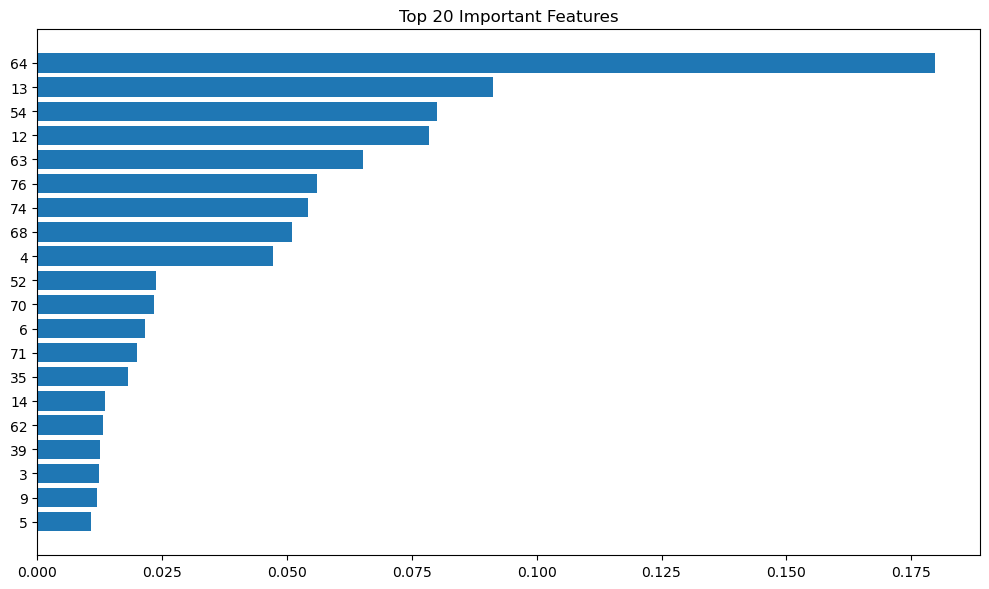

In [43]:
top20=importance.head(20)
plt.figure(figsize=(10,6))
plt.barh(top20["Feature"],top20["Importance"])
plt.gca().invert_yaxis()
plt.title("Top 20 Important Features")
plt.tight_layout()
plt.savefig("plots/xgboost_feature_importance.png")
plt.show()
